In [5]:
from torchvision import datasets, transforms
from torchvision.utils import save_image, make_grid
import glob
import torch
import torch.nn as nn
import numpy as np
import torch.distributions as td
import torch.utils.data
thresshold = 0.5
mnist_train_loader = torch.utils.data.DataLoader(datasets.MNIST('data/', train=True, download=True,
	                                                    transform=transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: (thresshold < x).float().squeeze())])),
	                                    batch_size=32, shuffle=True)
mnist_test_loader = torch.utils.data.DataLoader(datasets.MNIST('data/', train=False, download=True,
                                                transform=transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: (thresshold < x).float().squeeze())])),
                                    batch_size=32, shuffle=True)

In [103]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.stats import gaussian_kde
from torch.nn import functional as F
from tqdm import tqdm


class GaussianPrior(nn.Module):
    def __init__(self, M):
        """
        Define a Gaussian prior distribution with zero mean and unit variance.

                Parameters:
        M: [int] 
           Dimension of the latent space.
        """
        super(GaussianPrior, self).__init__()
        self.M = M
        self.mean = nn.Parameter(torch.zeros(self.M), requires_grad=False)
        self.std = nn.Parameter(torch.ones(self.M), requires_grad=False)

    def forward(self):
        """
        Return the prior distribution.

        Returns:
        prior: [torch.distributions.Distribution]
        """
        return td.Independent(td.Normal(loc=self.mean, scale=self.std), 1)


class GaussianEncoder(nn.Module):
    def __init__(self, encoder_net):
        """
        Define a Gaussian encoder distribution based on a given encoder network.

        Parameters:
        encoder_net: [torch.nn.Module]             
           The encoder network that takes as a tensor of dim `(batch_size,
           feature_dim1, feature_dim2)` and output a tensor of dimension
           `(batch_size, 2M)`, where M is the dimension of the latent space.
        """
        super(GaussianEncoder, self).__init__()
        self.encoder_net = encoder_net

    def forward(self, x):
        """
        Given a batch of data, return a Gaussian distribution over the latent space.

        Parameters:
        x: [torch.Tensor] 
           A tensor of dimension `(batch_size, feature_dim1, feature_dim2)`
        """
        mean, std = torch.chunk(self.encoder_net(x), 2, dim=-1)
        return td.Independent(td.Normal(loc=mean, scale=torch.exp(std)), 1)


class BernoulliDecoder(nn.Module):
    def __init__(self, decoder_net):
        """
        Define a Bernoulli decoder distribution based on a given decoder network.

        Parameters: 
        decoder_net: [torch.nn.Module]             
           The decoder network that takes as a tensor of dim `(batch_size, M) as
           input, where M is the dimension of the latent space, and outputs a
           tensor of dimension (batch_size, feature_dim1, feature_dim2).
        """
        super(BernoulliDecoder, self).__init__()
        self.decoder_net = decoder_net
        self.std = nn.Parameter(torch.ones(28, 28)*0.5, requires_grad=True)

    def forward(self, z):
        """
        Given a batch of latent variables, return a Bernoulli distribution over the data space.

        Parameters:
        z: [torch.Tensor] 
           A tensor of dimension `(batch_size, M)`, where M is the dimension of the latent space.
        """
        logits = self.decoder_net(z)
        return td.Independent(td.Bernoulli(logits=logits), 2)


class VAE(nn.Module):
    """
    Define a Variational Autoencoder (VAE) model.
    """
    def __init__(self, prior, decoder, encoder):
        """
        Parameters:
        prior: [torch.nn.Module] 
           The prior distribution over the latent space.
        decoder: [torch.nn.Module]
              The decoder distribution over the data space.
        encoder: [torch.nn.Module]
                The encoder distribution over the latent space.
        """
            
        super(VAE, self).__init__()
        self.prior = prior
        self.decoder = decoder
        self.encoder = encoder

    def elbo(self, x):
        """
        Compute the ELBO for the given batch of data.

        Parameters:
        x: [torch.Tensor] 
           A tensor of dimension `(batch_size, feature_dim1, feature_dim2, ...)`
           n_samples: [int]
           Number of samples to use for the Monte Carlo estimate of the ELBO.
        """
        q = self.encoder(x)
        z = q.rsample()
        elbo = torch.mean(self.decoder(z).log_prob(x) - td.kl_divergence(q, self.prior()), dim=0)
        return elbo

    def sample(self, n_samples=1):
        """
        Sample from the model.
        
        Parameters:
        n_samples: [int]
           Number of samples to generate.
        """
        z = self.prior().sample(torch.Size([n_samples]))
        return self.decoder(z).sample()
    
    def forward(self, x):
        """
        Compute the negative ELBO for the given batch of data.

        Parameters:
        x: [torch.Tensor] 
           A tensor of dimension `(batch_size, feature_dim1, feature_dim2)`
        """
        return -self.elbo(x)


def train(model, optimizer, data_loader, epochs, device):
    """
    Train a VAE model.

    Parameters:
    model: [VAE]
       The VAE model to train.
    optimizer: [torch.optim.Optimizer]
         The optimizer to use for training.
    data_loader: [torch.utils.data.DataLoader]
            The data loader to use for training.
    epochs: [int]
        Number of epochs to train for.
    device: [torch.device]
        The device to use for training.
    """
    model.train()

    total_steps = len(data_loader)*epochs
    progress_bar = tqdm(range(total_steps), desc="Training")

    for epoch in range(epochs):
        data_iter = iter(data_loader)
        for x in data_iter:
            x = x[0].to(device)
            optimizer.zero_grad()
            loss = model(x)
            loss.backward()
            optimizer.step()

            # Update progress bar
            progress_bar.set_postfix(loss=f"⠀{loss.item():12.4f}", epoch=f"{epoch+1}/{epochs}")
            progress_bar.update()

def get_aggregate_posterior_samples(model, device, max_batches=None):
    model.eval()
    zs = []

    data_loader = torch.utils.data.DataLoader(datasets.MNIST('data/', train=False, download=True,
                                                transform=transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: (thresshold < x).float().squeeze())])),
                                    batch_size=32*313, shuffle=True)

    with torch.no_grad():
        for i, x in enumerate(data_loader):
            x = x[0].to(device)
            q = model.encoder(x)
            z = q.rsample()
            zs.append(z.cpu())

            if max_batches is not None and i >= max_batches:
                break

    return torch.cat(zs, dim=0)

def get_prior_samples(model, n_samples = 32 * 313):
    with torch.no_grad():
        z = model.prior().sample((n_samples,))
    return z.cpu()

def reduce_to_2d(z):
    pca = PCA(n_components=2)
    return pca.fit_transform(z)

def plot_prior_vs_posterior(prior_z, post_z):
    plt.figure(figsize=(6,6))

    plt.scatter(prior_z[:,0], prior_z[:,1],
                alpha=0.3, label="Prior")

    plt.scatter(post_z[:,0], post_z[:,1],
                alpha=0.3, label="Aggregate Posterior")

    plt.legend()
    plt.title("Prior vs Aggregate Posterior")
    plt.savefig("Plot.png")

def compute_moments(z):
    mean = z.mean(dim=0)
    cov = torch.cov(z.T)
    return mean, cov

def evaluate_elbo(model, data_loader, device):
    model.eval()
    total_elbo = 0
    n = 0

    with torch.no_grad():
        for x in data_loader:
            x = x[0].to(device)
            total_elbo += model.elbo(x).item() * x.size(0)
            n += x.size(0)

    return total_elbo / n

In [79]:
def plot_latent_with_labels_PCA(model, data_loader, device, filename="latent_contour.png", max_batches=None):
    model.eval()

    zs = []
    ys = []

    with torch.no_grad():
        for i, (x, y) in enumerate(data_loader):
            x = x.to(device)

            q = model.encoder(x)
            z = q.rsample()          # use mean instead of rsample() for cleaner structure

            zs.append(z.cpu())
            ys.append(y)

            if max_batches is not None and i >= max_batches:
                break

    Z = torch.cat(zs, dim=0)        # (N, 2)
    Y = torch.cat(ys, dim=0)        # (N,)

    Z = reduce_to_2d(Z)

    assert Z.shape[1] == 2, "Latent dimension must be 2 for this plot."

    Z_np = Z
    Y_np = Y.numpy()

    # -------- Plot --------
    plt.figure(figsize=(8, 8), dpi=600)

    padding = 1.0
    x_min, x_max = Z_np[:, 0].min() - padding, Z_np[:, 0].max() + padding
    y_min, y_max = Z_np[:, 1].min() - padding, Z_np[:, 1].max() + padding

    x = np.linspace(-4, 4, 1000)
    y = np.linspace(-4, 4, 1000)
    X, Y_grid = np.meshgrid(x, y)

    # Standard Gaussian density
    Z_density = stats.multivariate_normal(mean = [0, 0], cov = [1, 1]).pdf(np.dstack((X, Y_grid)))
    plt.contour(X, Y_grid, Z_density, levels=10, colors="black", linewidths = 0.5, linestyles="dashed")

    # Scatter points colored by digit label
    for digit in range(10):
        idx = (Y_np == digit)
        plt.scatter(Z_np[idx, 0], Z_np[idx, 1],
                    s=10, alpha=0.6, linewidth=0.3, edgecolors="black", label=f"digit={digit}")

    plt.legend(markerscale=2, fontsize=8)
    plt.xlabel("z1")
    plt.ylabel("z2")
    plt.title("Latent Space with Prior Contours")
    plt.axis("equal")
    # plt.savefig(filename)
    plt.show()

def reduce_to_2d(z):
    pca = PCA(n_components=2)
    return pca.fit_transform(z)

In [73]:
# Define prior distribution
M = 128
prior = GaussianPrior(M)

# Define encoder and decoder networks
encoder_net = nn.Sequential(
nn.Flatten(),
nn.Linear(784, 512),
nn.ReLU(),
nn.Linear(512, 512),
nn.ReLU(),
nn.Linear(512, M*2),
)

decoder_net = nn.Sequential(
nn.Linear(M, 512),
nn.ReLU(),
nn.Linear(512, 512),
nn.ReLU(),
nn.Linear(512, 784),
nn.Unflatten(-1, (28, 28))
)

# Define VAE model
decoder = BernoulliDecoder(decoder_net)
encoder = GaussianEncoder(encoder_net)
model_128 = VAE(prior, decoder, encoder).to("cuda")

model_128.load_state_dict(torch.load("model_128.pt", map_location=torch.device("cuda")))

<All keys matched successfully>

In [89]:
for x in mnist_test_loader:
    q = model_128.encoder(x[0].to("cuda"))
    z = q.rsample()
    print(td.kl_divergence(q, model_128.prior()))
    print(model_128.decoder(z).log_prob(x[0].to("cuda")))
    break
    
for x in mnist_test_loader:
    q = model.encoder(x[0].to("cuda"))
    z = q.rsample()
    print(td.kl_divergence(q, model.prior()))
    print(model.decoder(z).log_prob(x[0].to("cuda")))
    break
    
# plot_latent_with_labels_PCA(model_128, mnist_test_loader, "cuda", max_batches = 32)

tensor([21.2621, 24.7543, 20.9288, 19.9090, 22.1017, 20.9234, 21.1207, 20.8176,
        27.9226, 20.4626, 23.1643, 22.9819, 22.2082, 20.7369, 20.4955, 25.3656,
        20.7936, 22.5438, 24.7058, 20.6691, 20.2753, 21.0734, 21.7282, 22.0106,
        21.6027, 21.4956, 20.7231, 24.8503, 17.2195, 22.5957, 21.7544, 17.9244],
       device='cuda:0', grad_fn=<SumBackward1>)
tensor([ -64.1050,  -98.2556, -122.2971,  -54.1492,  -65.0921,  -76.0943,
         -39.7342,  -33.8721,  -78.5836,  -62.9180,  -68.5564,  -45.4471,
         -49.3745,  -56.3594,  -75.2965,  -84.6665,  -73.8368,  -62.3469,
         -71.0737, -102.3439,  -92.1058, -103.6051,  -69.2974,  -44.7378,
         -95.6621,  -75.3088,  -54.6698,  -65.1255,  -34.5803,  -66.7570,
         -53.9612,  -23.6493], device='cuda:0', grad_fn=<SumBackward1>)
tensor([ 5.6022,  5.3522,  7.9580,  6.1486,  8.4938,  6.5217,  6.0194, 10.2270,
        12.8663,  7.9573,  5.9762,  5.7383,  8.5909,  6.7834,  6.6076,  5.4650,
         7.5963,  5.7113,  6.

In [99]:
model.eval()
with torch.no_grad():
    for x in torch.utils.data.DataLoader(datasets.MNIST('data/', train=False, download=True,
                                                transform=transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: (thresshold < x).float().squeeze())])),
                                    batch_size=32*313, shuffle=True):
        print(x[1].shape)
        print(model.elbo(x[0].to("cuda")))

torch.Size([10000])
tensor(-138.2424, device='cuda:0')


In [104]:
posterior_samples = get_aggregate_posterior_samples(
		model, device = "cuda", max_batches=200
		)

prior_samples = get_prior_samples(
    model
)

mean_q, cov_q = compute_moments(posterior_samples)

In [106]:
print(posterior_samples.shape)

torch.Size([10000, 2])


In [6]:
x, y = next(iter(mnist_train_loader))
print("x shape:", x.shape)
print("y shape:", y.shape)
print("x dtype:", x.dtype)
print("y example:", y[:10])

x shape: torch.Size([32, 28, 28])
y shape: torch.Size([32])
x dtype: torch.float32
y example: tensor([1, 4, 9, 5, 6, 6, 9, 3, 4, 7])


In [25]:
import matplotlib.pyplot as plt
from scipy import stats
x = np.linspace(-3, 3, 200)
y = np.linspace(-3, 3, 200)
X, Y_grid = np.meshgrid(x, y)

In [115]:
def plot_latent_with_labels(model, data_loader, device, filename="latent_contour.png", max_batches=None):
    model.eval()

    zs = []
    ys = []

    with torch.no_grad():
        for i, (x, y) in enumerate(data_loader):
            x = x.to(device)

            q = model.encoder(x)
            z = q.rsample()

            zs.append(z.cpu())
            ys.append(y)

            if max_batches is not None and i >= max_batches:
                break

    Z = torch.cat(zs, dim=0)        # (N, 2)
    Y = torch.cat(ys, dim=0)        # (N,)

    assert Z.shape[1] == 2, "Latent dimension must be 2 for this plot."

    Z_np = Z.numpy()
    Y_np = Y.numpy()

    # -------- Plot --------
    plt.figure(figsize=(4, 4), dpi=600)

    padding = 1.0
    x_min, x_max = Z_np[:, 0].min() - padding, Z_np[:, 0].max() + padding
    y_min, y_max = Z_np[:, 1].min() - padding, Z_np[:, 1].max() + padding

    x = np.linspace(-4, 4, 1000)
    y = np.linspace(-4, 4, 1000)
    X, Y_grid = np.meshgrid(x, y)

    # Standard Gaussian density
    Z_density = stats.multivariate_normal(mean = [0, 0], cov = [1, 1]).pdf(np.dstack((X, Y_grid)))
    plt.contour(X, Y_grid, Z_density, levels=10, colors="black", linewidths = 0.5, linestyles="dashed")

    # Scatter points colored by digit label
    for digit in range(10):
        idx = (Y_np == digit)
        plt.scatter(Z_np[idx, 0], Z_np[idx, 1],
                    s=10, alpha=0.6, linewidth=0.3, edgecolors="black", label=f"digit={digit}")

    plt.legend(markerscale=2, fontsize=8)
    plt.xlabel("z1")
    plt.ylabel("z2")
    plt.title("Latent Space with Prior Contours")
    plt.axis("equal")
    plt.savefig(filename)
    plt.show()

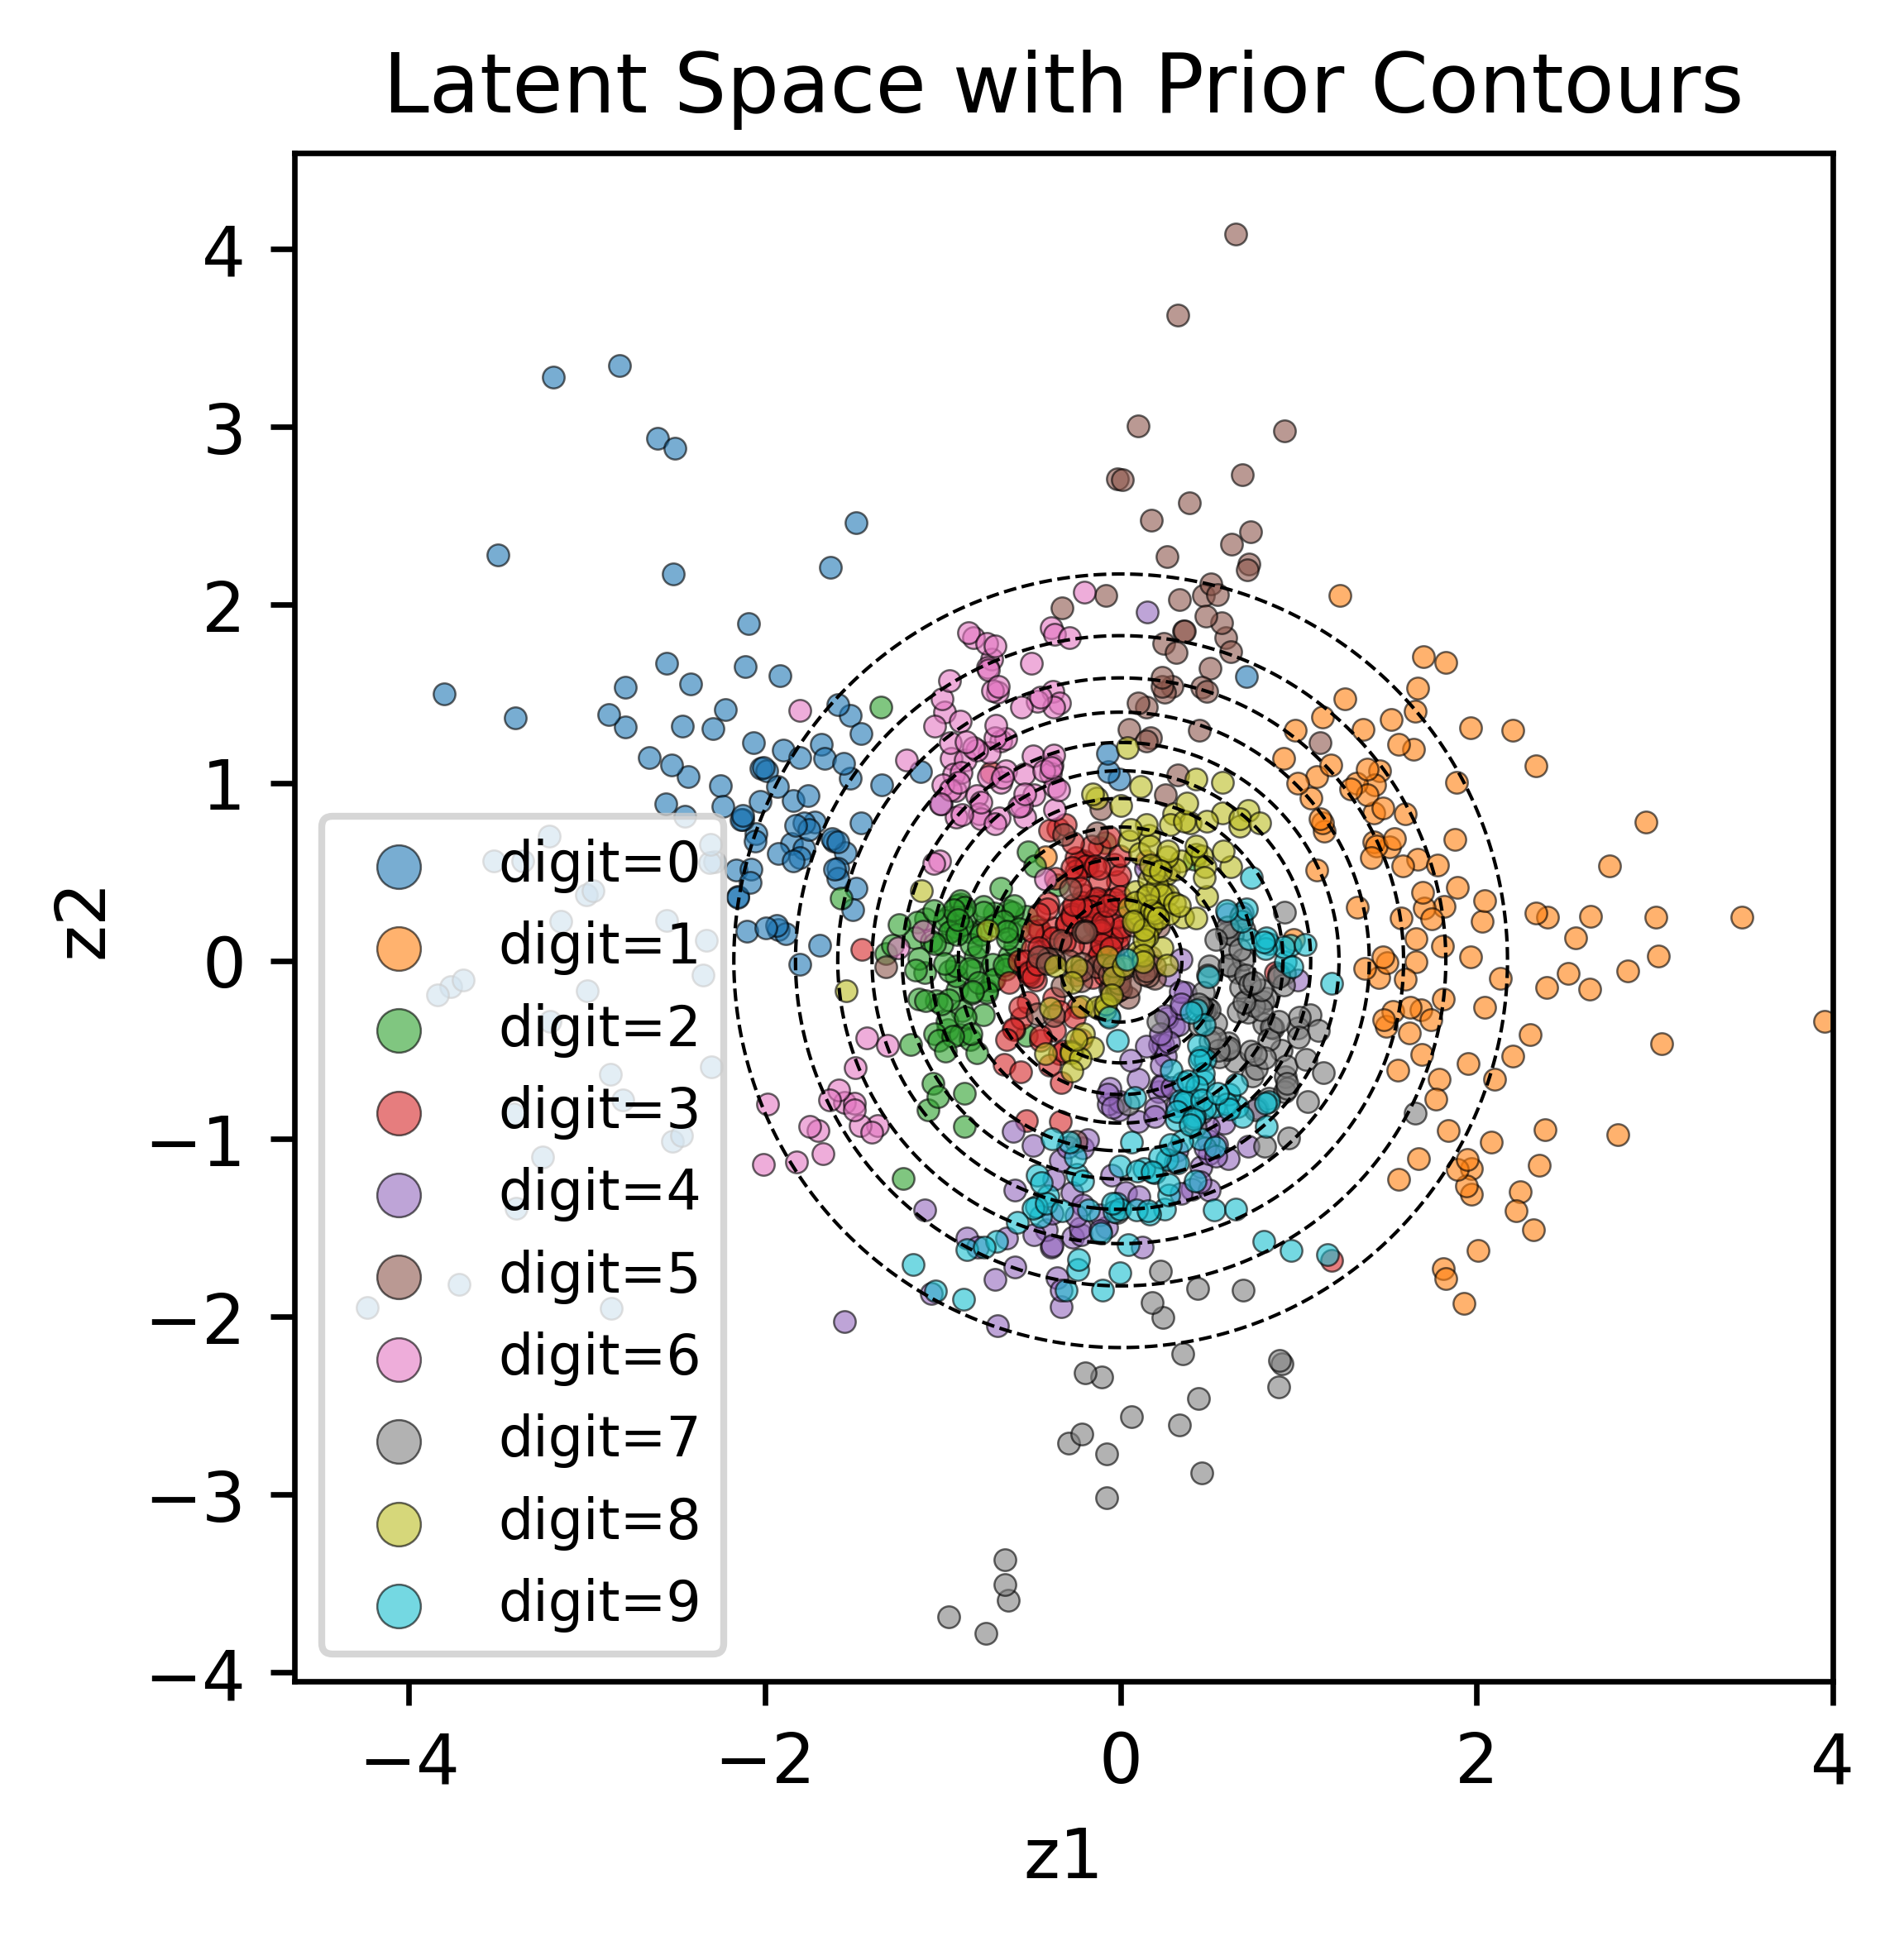

In [117]:
# Define prior distribution
M = 2
prior = GaussianPrior(M)

# Define encoder and decoder networks
encoder_net = nn.Sequential(
nn.Flatten(),
nn.Linear(784, 512),
nn.ReLU(),
nn.Linear(512, 512),
nn.ReLU(),
nn.Linear(512, M*2),
)

decoder_net = nn.Sequential(
nn.Linear(M, 512),
nn.ReLU(),
nn.Linear(512, 512),
nn.ReLU(),
nn.Linear(512, 784),
nn.Unflatten(-1, (28, 28))
)

# Define VAE model
decoder = BernoulliDecoder(decoder_net)
encoder = GaussianEncoder(encoder_net)
model = VAE(prior, decoder, encoder).to("cuda")

model.load_state_dict(torch.load("model_base_2.pt", map_location=torch.device("cuda")))

# plot_prior_vs_posterior(torch.tensor(prior_2d),
#                 torch.tensor(post_2d))
plot_latent_with_labels(model, mnist_test_loader, "cuda", max_batches = 32)

In [150]:
def plot_mog_contours(prior, model, loader, lim=14, grid=300, levels=15,
                      max_batch=32, use_mean=False, alpha=0.6, s=8, linewidth = 0.5, filename = "contour.png"):
    prior.eval()
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    xs = torch.linspace(-lim, lim, grid, device=device)
    ys = torch.linspace(-lim, lim, grid, device=device)
    X, Y = torch.meshgrid(xs, ys, indexing="xy")
    pts = torch.stack([X.reshape(-1), Y.reshape(-1)], dim=1)

    with torch.no_grad():
        logp = prior().log_prob(pts).reshape(grid, grid)
        mu = prior.mu.detach().cpu().numpy()

    zs = []
    ys_lab = []
    # collected = 0

    with torch.no_grad():
        for i, (x, y) in enumerate(loader):
            x = x.to("cuda")
            q = model.encoder(x)

            if use_mean:
                z = q.base_dist.loc
            else:
                z = q.rsample()

            zs.append(z.detach().cpu())
            ys_lab.append(y.detach().cpu())
            # collected += x.size(0)
            if max_batch is not None and i >= max_batch:
                break

    Z = torch.cat(zs, dim=0).numpy()
    Ylab = torch.cat(ys_lab, dim=0).numpy()

    # --- Plot ---
    plt.figure(figsize=(7, 6), dpi = 600)
    cs = plt.contour(X.cpu().numpy(), Y.cpu().numpy(), logp.cpu().numpy(), levels=levels, linewidths = linewidth)
    plt.clabel(cs, inline=True, fontsize=8)

    sc = plt.scatter(Z[:, 0], Z[:, 1], c=Ylab, cmap="tab10", s=s, alpha=alpha)
    plt.colorbar(sc, ticks=list(range(10)), label="Digit label")

    plt.scatter(mu[:, 0], mu[:, 1], marker="x", s=80)

    plt.title("MoG Prior Contours (log p(z)) + Encoded Data (colored by class)")
    plt.xlabel("z1")
    plt.ylabel("z2")
    plt.grid(True)
    plt.savefig(filename)
    plt.show()

# plot_mog_contours(prior, model, mnist_test_loader, lim = 5, max_batch = 64, use_mean = True)

In [140]:
class MoGPrior(nn.Module):
    def __init__(self, M, K):
        super().__init__()
        self.M = M
        self.K = K
        self.mu = nn.Parameter(torch.randn(K, M) * 2.0)
        self.log_std = nn.Parameter(torch.zeros(K, M) - 0.5)
        self.logits = nn.Parameter(torch.zeros(K))

    def forward(self):
        mix = td.Categorical(logits=self.logits)
        comp = td.Independent(td.Normal(self.mu, torch.exp(self.log_std)), 1)
        return td.MixtureSameFamily(mix, comp)


class GaussPrior(nn.Module):
    def __init__(self):
        super().__init__()
        self.M = 2
        self.K = 1

        self.mu = nn.Parameter(torch.zeros(self.K, self.M), requires_grad=False)
        self.log_std = nn.Parameter(torch.zeros(self.K, self.M), requires_grad=False)
        self.logits = nn.Parameter(torch.zeros(self.K), requires_grad=False)

    def forward(self):
        mix = td.Categorical(logits=self.logits)
        comp = td.Independent(td.Normal(self.mu, torch.exp(self.log_std)), 1)
        return td.MixtureSameFamily(mix, comp)


class GaussianEncoder(nn.Module):
    def __init__(self, encoder_net):
        super().__init__()
        self.encoder_net = encoder_net

    def forward(self, x):
        mean, log_std = torch.chunk(self.encoder_net(x), 2, dim=-1)

        log_std = torch.clamp(log_std, min=-10.0, max=10.0)
        return td.Independent(td.Normal(mean, torch.exp(log_std)), 1)


class BernoulliDecoder(nn.Module):
    def __init__(self, decoder_net):
        super().__init__()
        self.decoder_net = decoder_net

    def forward(self, z):
        logits = self.decoder_net(z)
        return td.Independent(td.Bernoulli(logits=logits), 2)


class VAE(nn.Module):
    def __init__(self, prior, decoder, encoder):
        super().__init__()
        self.prior = prior
        self.decoder = decoder
        self.encoder = encoder

    def elbo(self, x):
        q = self.encoder(x)
        z = q.rsample()
        pz = self.prior()

        log_px = self.decoder(z).log_prob(x)
        kl = q.log_prob(z) - pz.log_prob(z)

        return torch.mean(log_px - kl)

    def forward(self, x):
        return -self.elbo(x)

In [146]:
M = 2
K = 10

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

prior = MoGPrior(M, K).to(device)  # use this code if u want prior

# prior = GaussPrior().to(device)  # use this if you want standard gaussian N(0,I)

encoder_net = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 512),
    nn.ReLU(),
    nn.Linear(512, 512),
    nn.ReLU(),
    nn.Linear(512, M * 2),
)

decoder_net = nn.Sequential(
    nn.Linear(M, 512),
    nn.ReLU(),
    nn.Linear(512, 512),
    nn.ReLU(),
    nn.Linear(512, 784),
    nn.Unflatten(-1, (28, 28))
)

encoder = GaussianEncoder(encoder_net)
decoder = BernoulliDecoder(decoder_net)
model_mog = VAE(prior, decoder, encoder).to(device)
model_mog.load_state_dict(torch.load("models/VAE_MoG.pt", map_location=torch.device("cuda")))

<All keys matched successfully>

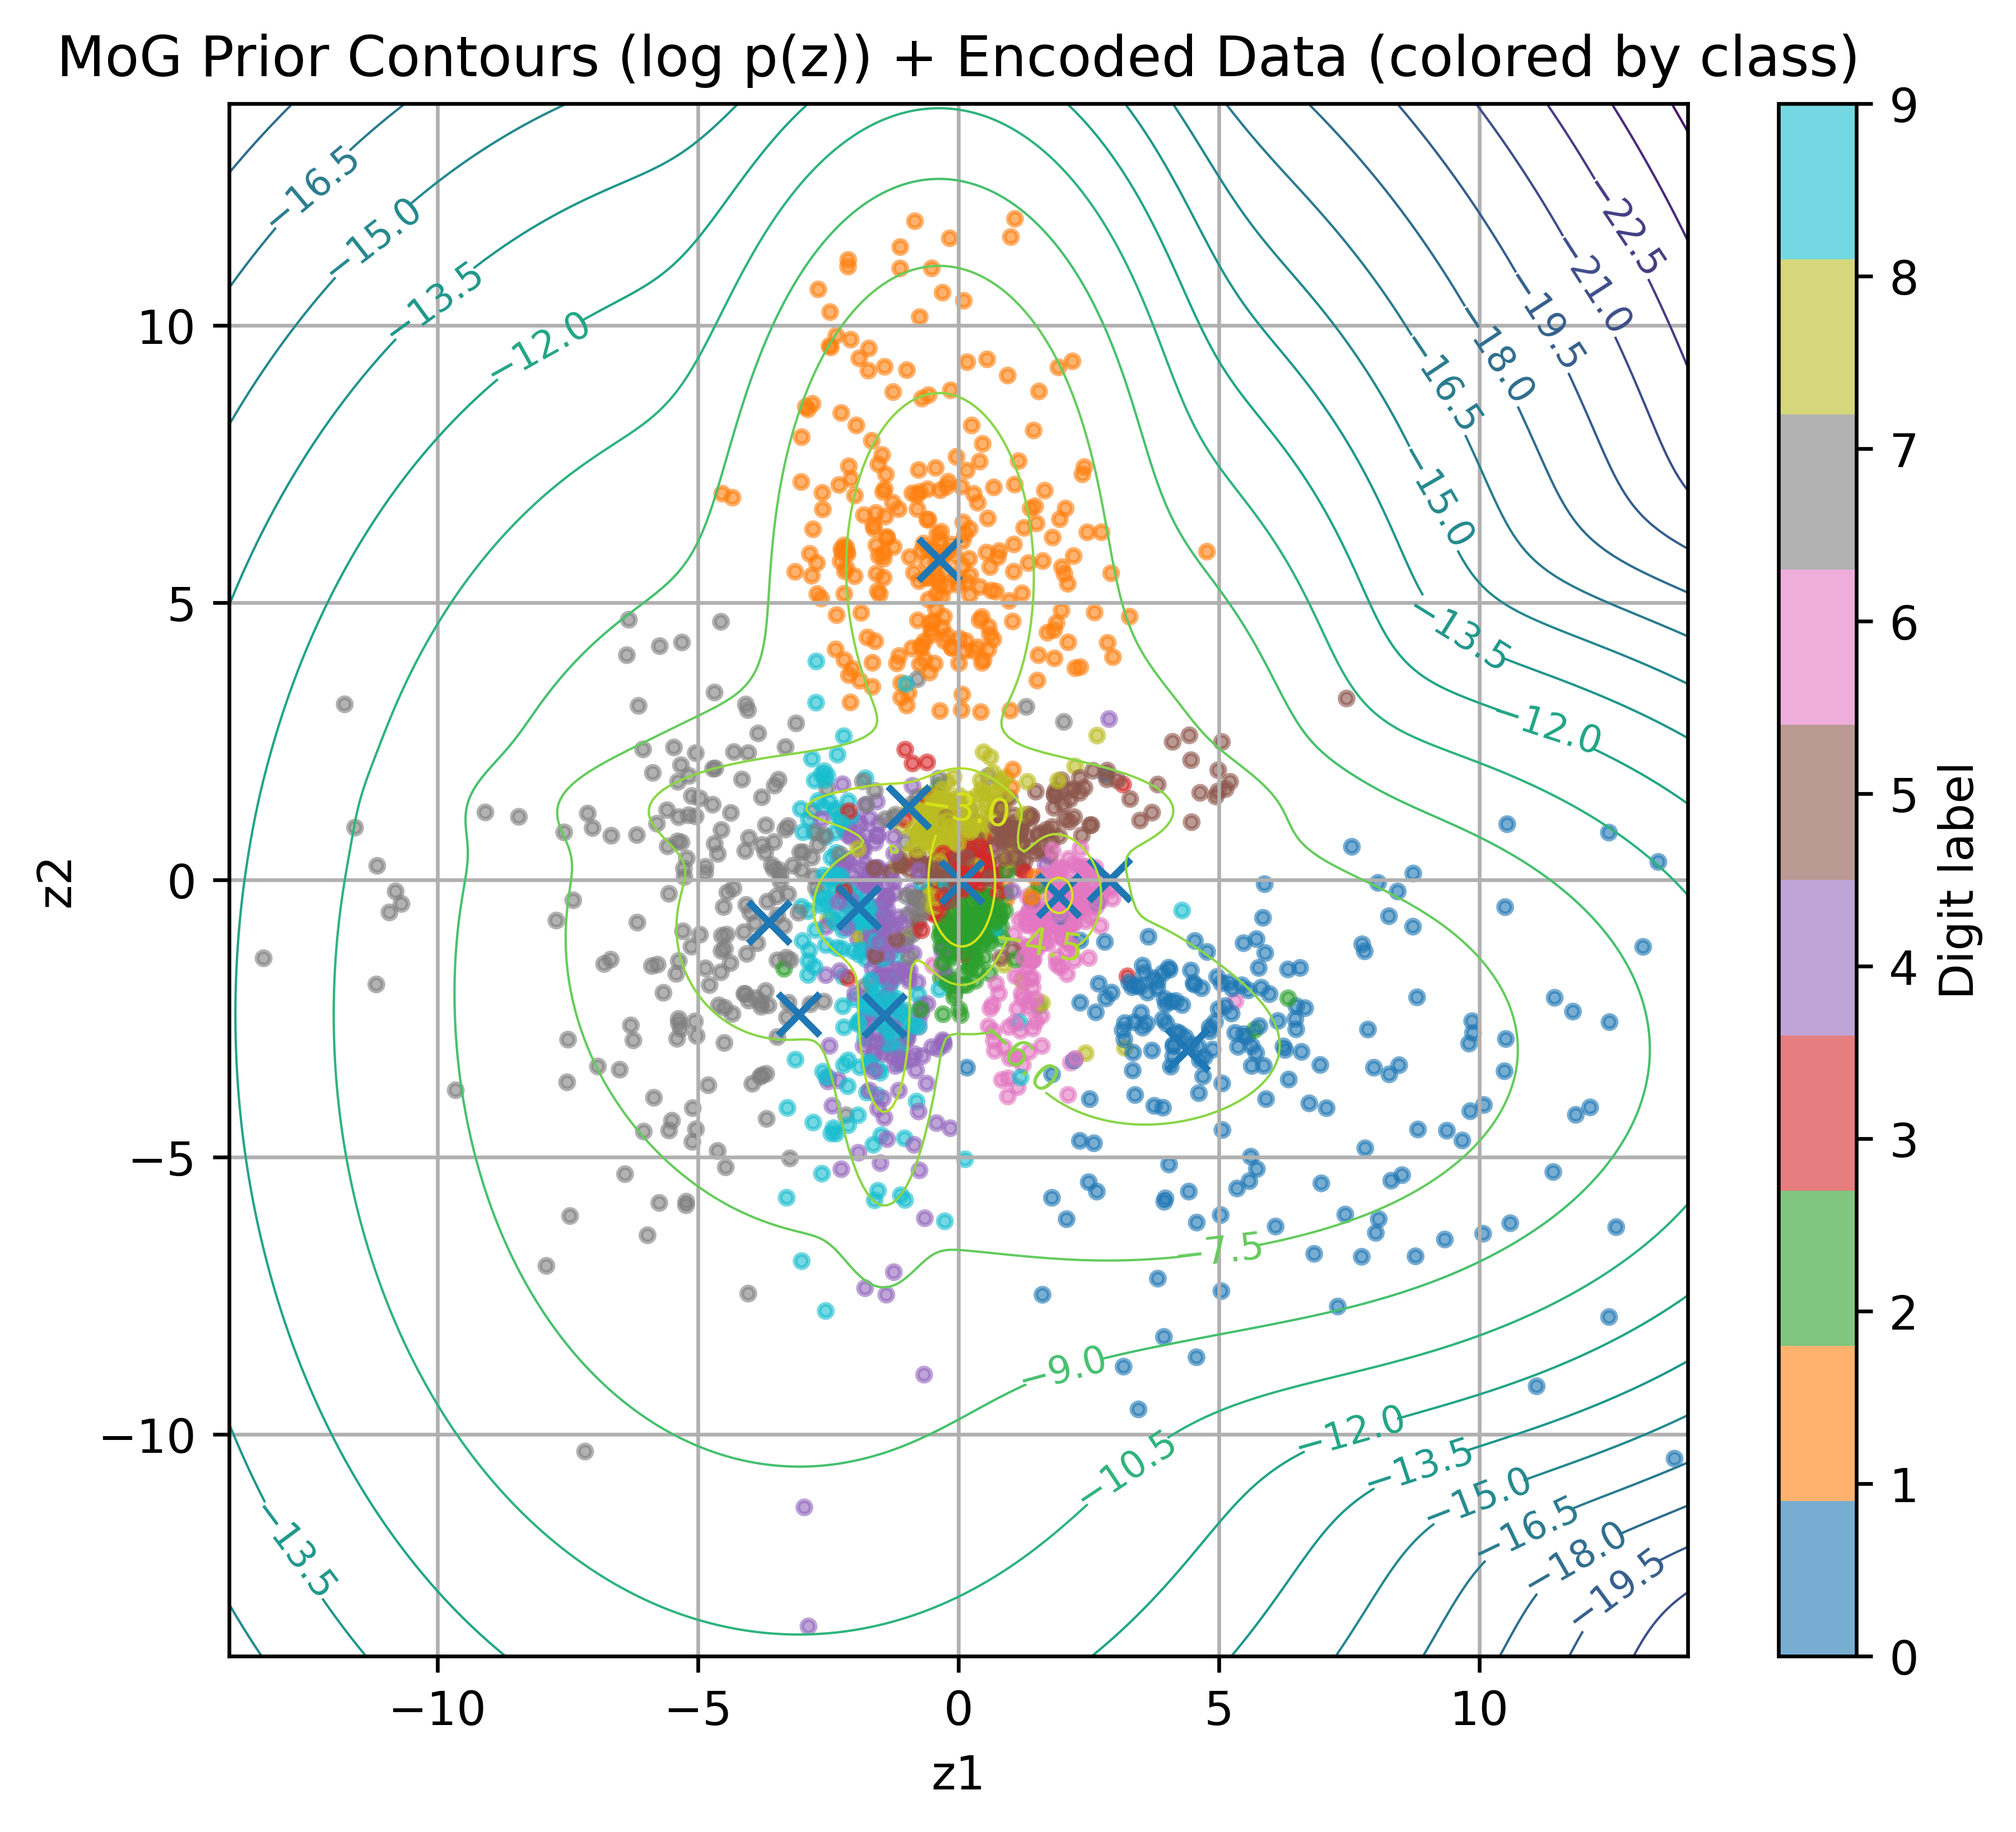

In [151]:
plot_mog_contours(prior, model_mog, mnist_test_loader, lim = 14, max_batch = 64, use_mean = True, filename = "contour_mog.png")

0
1
2
3
4
5
6
7
8
9


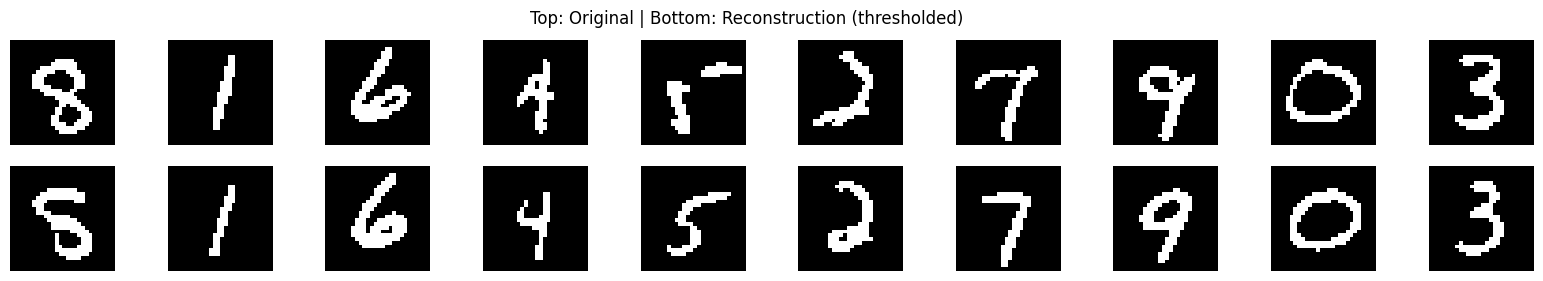

In [163]:
def show_reconstructions(model, loader, filename = "sample_with_original.png", n=10, thr=0.5):
    model.eval()
    
    # Get one batch
    x_batch, y_batch = next(iter(loader))
    x_batch = x_batch.to(device)
    y_batch = y_batch.to(device)
    
    selected_images = []
    selected_labels = []
    seen = set()
    
    for img, label in zip(x_batch, y_batch):
        label_item = label.item()
        if label_item not in seen:
            selected_images.append(img)
            selected_labels.append(label)
            seen.add(label_item)
        if len(seen) == 10:   # MNIST has 10 classes
            break
    
    # Stack into tensor
    x = torch.stack(selected_images)          # shape: (10, 1, 28, 28)
    y = torch.stack(selected_labels)          # shape: (10,)

    with torch.no_grad():
        z = model.encoder(x).rsample()
        probs = model.decoder(z).mean
        xhat = (probs >= thr).float()

    x = x.cpu()
    xhat = xhat.cpu()

    plt.figure(figsize=(2 * n, 3))
    for i in range(n):
        plt.subplot(2, n, i + 1)
        print(i)
        plt.imshow(x[i], cmap="gray", vmin=0, vmax=1)
        plt.axis("off")

        plt.subplot(2, n, n + i + 1)
        plt.imshow(xhat[i], cmap="gray", vmin=0, vmax=1)
        plt.axis("off")

    plt.suptitle("Top: Original | Bottom: Reconstruction (thresholded)")
    plt.savefig(filename)
    plt.show()

show_reconstructions(model_mog, mnist_test_loader, filename = "sample_mog.png")

Saved generated images to sample_mog_for_exercise_2.png


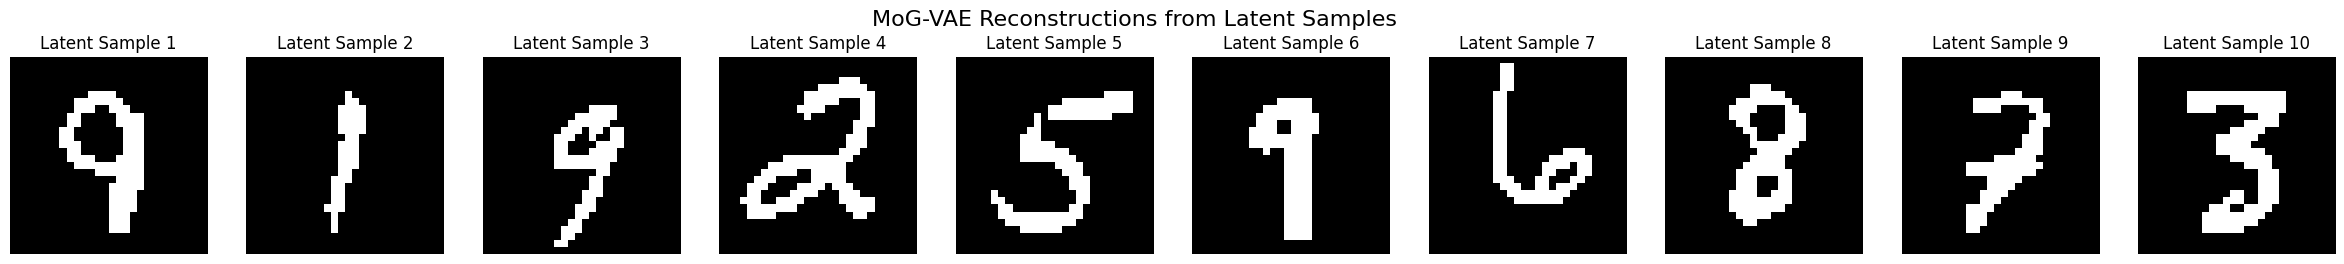

In [168]:
model_mog.eval()
x, _ = next(iter(mnist_test_loader))
x = x[:10].to(device)

with torch.no_grad():
    z = model_mog.encoder(x).rsample()
    xhat = model_mog.decoder(z).mean

x = x.cpu()
xhat = xhat.cpu()

imgs = x.view(-1, 28, 28).numpy()
imgs = (imgs + 1.0) / 2.0  # Scale back to [0, 1] for plotting

# Dynamically adjust figure size based on the number of samples
fig, axes = plt.subplots(1, 10, figsize=(3 * 10, 3))

# if num_samples == 1:
#     axes = [axes]

for i in range(10):
    axes[i].imshow(imgs[i].clip(0, 1), cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(f"Latent Sample {i + 1}")
#
# plt.suptitle(f"Latent DDPM (Beta={args.beta})")
# plt.tight_layout()

filename = f"sample_mog_for_exercise_2.png"
plt.suptitle("MoG-VAE Reconstructions from Latent Samples", fontsize=16)
plt.savefig(filename, bbox_inches='tight', dpi=600)
print(f"Saved generated images to {filename}")
